## Interquartile analysis on price

In [8]:
import polars as pl
import matplotlib.pyplot as plt
import psycopg2
import seaborn as sns
from dotenv import load_dotenv
load_dotenv('/home/luifer/Numbersdontlie/Data-Science-Piscine/day2/ex00/.env', override=True)
import os
import vegafusion as vf

In [2]:
user = os.getenv('POSTGRES_USER')
password = os.getenv('POSTGRES_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
dbname = os.getenv('POSTGRES_DB')

uri = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"

In [3]:
# generate the query to get # of customers monthly
query = """
SELECT *
FROM customers
WHERE event_type = 'purchase'
ORDER BY event_time ASC;
"""


In [4]:
# generate the dataframe
with psycopg2.connect(
    user=user,
    password=password,
    host=host,
    port=port,
    dbname=dbname,
) as conn:
    df_purchase = pl.read_database(
        query,
        conn,
        infer_schema_length=10_000,
        schema_overrides={
            "product_id": pl.Int64,
            "user_id": pl.Int64,
            "price": pl.Float64,
        },
    )

In [5]:
# generate the dataframe with the interquartile metrics
df_iqc = (
    df_purchase.select(
        [
            pl.col("price").mean().alias("mean"),
            pl.col("price").median().alias("median"),
            pl.col("price").min().alias("min"),
            pl.col("price").max().alias("max"),
            pl.col("price").quantile(0.25).alias("Q1"),
            pl.col("price").quantile(0.50).alias("Q2"),
            pl.col("price").quantile(0.75).alias("Q3"),            
        ]
    )
)
print(df_iqc)

shape: (1, 7)
┌──────────┬────────┬────────┬────────┬──────┬─────┬─────┐
│ mean     ┆ median ┆ min    ┆ max    ┆ Q1   ┆ Q2  ┆ Q3  │
│ ---      ┆ ---    ┆ ---    ┆ ---    ┆ ---  ┆ --- ┆ --- │
│ f64      ┆ f64    ┆ f64    ┆ f64    ┆ f64  ┆ f64 ┆ f64 │
╞══════════╪════════╪════════╪════════╪══════╪═════╪═════╡
│ 4.933148 ┆ 3.0    ┆ -79.37 ┆ 327.78 ┆ 1.59 ┆ 3.0 ┆ 5.4 │
└──────────┴────────┴────────┴────────┴──────┴─────┴─────┘


In [12]:
prices = df_purchase["price"].to_frame()

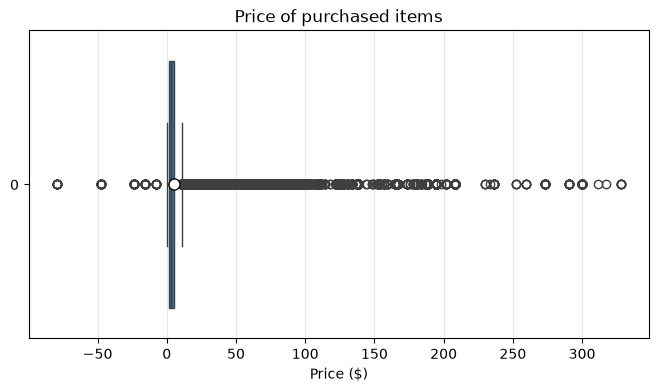

In [16]:
# Graph 1 price of purchased items
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=prices,
    orient='h',
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8},
)

plt.title("Price of purchased items")
plt.xlabel("Price ($)")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [9]:
# Graph 2 avg basket price per user
df_basket = (
    df_purchase
    .group_by("user_session")
    .agg(
        pl.col("price").sum().alias("basket_total")
    )
)

/tmp/ipykernel_8444/1102978202.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


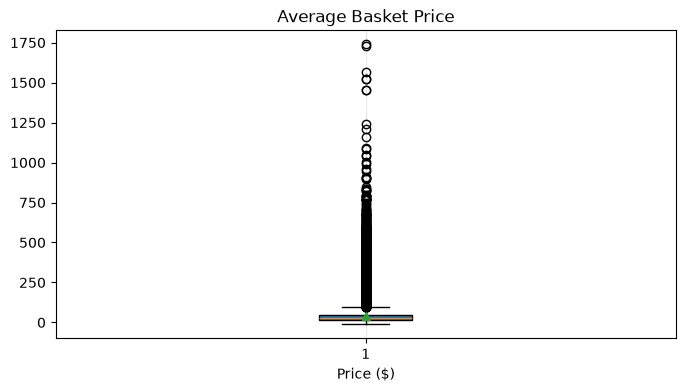

In [12]:
basket_prices = df_basket["basket_total"].to_list()

plt.figure(figsize=(8, 4))
plt.boxplot(
    basket_prices,
    vert=True,
    patch_artist=True,
    showmeans=True
)
plt.title("Average Basket Price")
plt.xlabel("Price ($)")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [13]:
# Graph 3 Avg spend per customer
df_customer = (
    df_purchase
    .group_by("user_id")
    .agg(
        pl.col("price").sum().alias("total_spent")
    )
)

/tmp/ipykernel_8444/3419102902.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


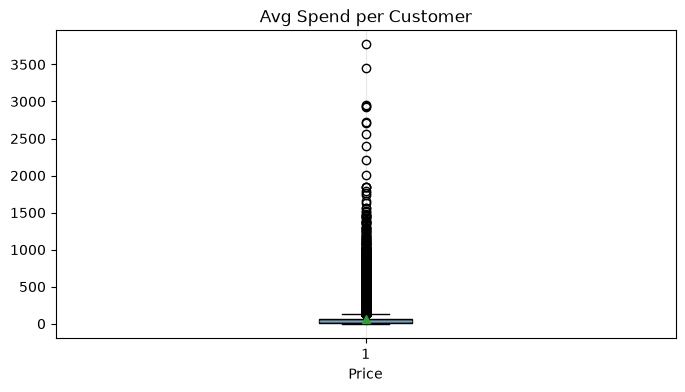

In [14]:
# plot
customer_spending = df_customer["total_spent"].to_list()
plt.figure(figsize=(8, 4))

plt.boxplot(
    customer_spending,
    vert=True,
    patch_artist=True,
    showmeans=True
)

plt.title("Avg Spend per Customer")
plt.xlabel("Price")
plt.grid(axis="x", alpha=0.3)
plt.show()

/tmp/ipykernel_8444/409979659.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[0].boxplot(prices, vert=False)
/tmp/ipykernel_8444/409979659.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(basket_prices, vert=False)
/tmp/ipykernel_8444/409979659.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[2].boxplot(customer_spending, vert=False)


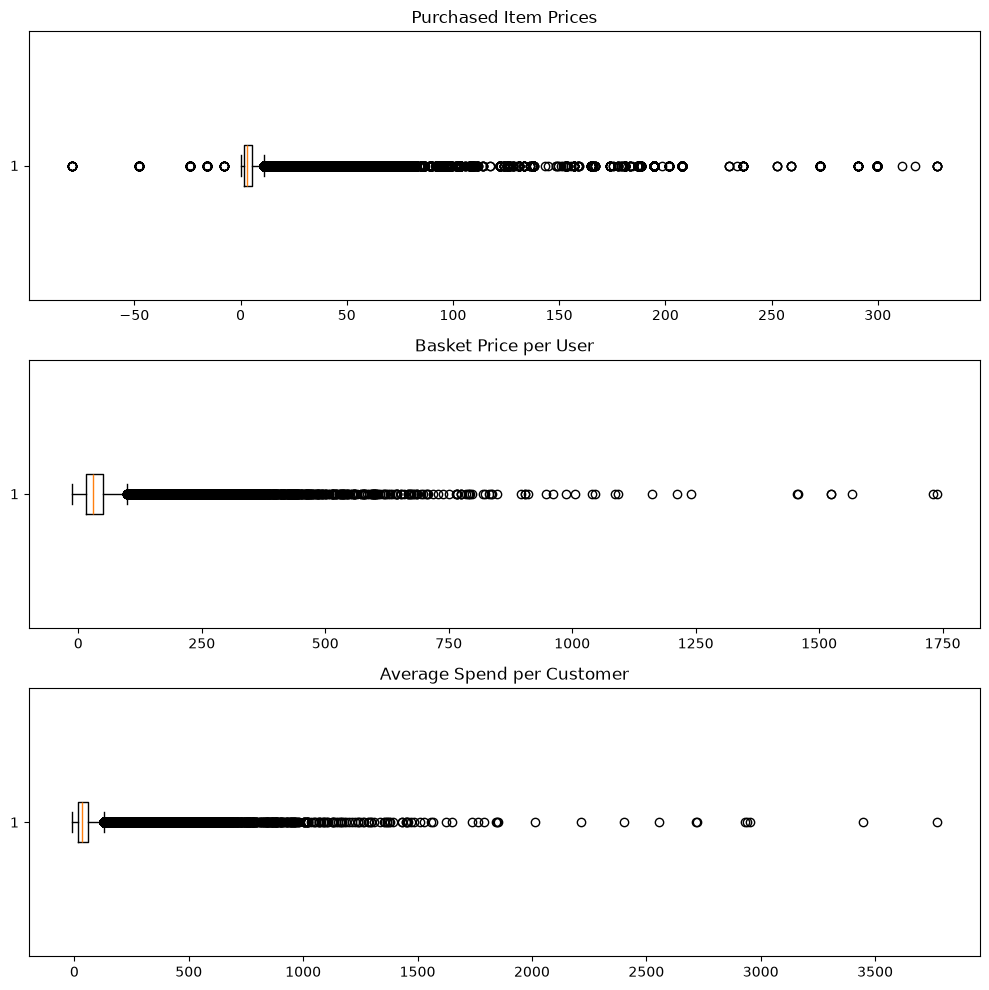

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

ax[0].boxplot(prices, vert=False)
ax[0].set_title("Purchased Item Prices")

ax[1].boxplot(basket_prices, vert=False)
ax[1].set_title("Basket Price per User")

ax[2].boxplot(customer_spending, vert=False)
ax[2].set_title("Average Spend per Customer")

plt.tight_layout()
plt.show()